# Experiments with new optimiser
------

## Imports

In [33]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from math import pi, sqrt, e, log
import functions as func
from scipy.optimize import minimize, Bounds
from tqdm import tqdm
import seaborn as sns
from importlib import reload
reload(func)

<module 'functions' from 'C:\\Users\\Mahfuzah Fariha\\OneDrive - The University of Nottingham\\Documents\\Year 4\\Research Project\\Code\\plots\\higher_costs\\functions.py'>

## Constants

In [34]:
N = 2 ** 20
N_16 = 2 ** 16
p = 1-e**-2 # our table coverage

# constants for plotting
NUM_COLORS = 20
LINE_STYLES = ['solid', 'dashed', 'dashdot', 'dotted']
NUM_STYLES = len(LINE_STYLES)

## Numerical Optimisation

In [35]:
# Optimise 
# add vcost to bound the optimisation
def optimise_kj(N, p, alpha, factor, lower_bound):   # add v_cost if want vanilla cost to be set beforehand
    # t = round(log(1-p)/log(1-N**(-1/3))) # Calculate t
    t = 350
    mt_target = N**(2/3) # our target mt
    m_0 = round(mt_target/(1-alpha))    # our starting m_0
    
    ## set the bound and target function
    # lower bounds and upper bounds for the input variables
    # first 10 columns have a lower bound of 5 then 1 after that
    # bound = Bounds([5 if i < 2 else 1 for i in range(t)], [float("inf") for i in range(t)])
    bound = Bounds([lower_bound for i in range(t)], [float("inf") for i in range(t)])
    
    # our target function that needs to be > 0
    # instead of using the target function, we can use the cost function as the objective function
    # need to get the cost of a vanilla rainbow table with the same parameters
    
    # Const * P(vanilla) - P(cherry) > 0
    v_cost, m = func.vanilla_cost(N, m_0, t)
    v_cost = v_cost * factor
    ineq_cons = {'type': 'ineq', 'fun' : lambda x: v_cost - func.cost(x, N, m_0)[0]}

    ## use 1 as starting values for cherry-picking
    starting_values = [1 for i in range(t)]
    
    ## call the optimizer
    # maximise the 
    # 5000000 normally
    res = minimize(lambda Kj: func.m_t(Kj, N, m_0), starting_values, bounds=bound, constraints=ineq_cons,method = "SLSQP", options={'disp': True, "maxiter": 5000000, "eps": 1, "ftol": 1e-3})
    
    ## res.x is the result of the optimization
    final_cost, m_values = func.cost(res.x, N, m_0) # calculate the final cost and m values
    return res.x, m_0, final_cost, m_values

## Test lower cost bounds with new optimiser

In [36]:
# first do 1.125 1.25 and 1.5 for N = 2^16 like we did for N = 2^20

def test_cost_factors_around_1(N, p, alphas, factors):
    
    # for each factor
    for factor in tqdm(factors, desc="Processing factors"):
        # place to store all the kj's for the factor
        results = []
        
        # for each alpha
        for alpha in tqdm(alphas, desc="Processing alphas"):
            K_js, m_0, final_cost, m_values = optimise_kj(N, p, alpha, factor)
            # plot_kjs_cost(N, K_js, m_0, alpha, factor)
            results.append([K_js, m_0, final_cost, m_values])
            
        # store all kj's for the factor in a .pickle file
        with open(f"N_16/around_1/{factor}P(V)/factor_{factor}_5_column_lowerbound_10.pickle", "wb") as f:
            pickle.dump(results, f)
        
        # plot all alpha kjs on the same graph
        func.plot_all_alpha(results, N_16, factor)
        

In [37]:
# run all the factors around 1

# factors = [1.5, 1.25, 1.125]
# alphas = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
# test_cost_factors_around_1(N_16, p, alphas, factors)

## Compare change in endpoints with different lower bounds

In [38]:
# for lower bounds : 1 , 3, 5
# have two plots : one for change in endpoints and one for change in cost
# one set of graphs for each cost 

def compare_endpoints(factor, alphas, bounds, results_list):
    # get figure ready
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    
    # for each factor
    for i in range(len(bounds)):
        # extract the endpoints for each alpha
        endpoints = []
        
        # get the results for the factor
        results = results_list[i]
        
        # loop through each alpha in results and get the last m value
        for res in results:
            endpoints.append(res[3][-1])
        
        # plot the endpoints
        ax.plot(endpoints, label=f"lower bound = {bounds[i]}")
        
    # add the legend
    ax.legend()
    
    # add axis labels
    ax.set_ylabel("Number of endpoints", **{"fontsize": 12, "labelpad": -2})
    ax.set_xlabel("alpha", **{"fontsize": 12})
    ax.set_xticklabels(alphas)
        
    # add title
    fig.suptitle("Difference in endpoints for different lower bounds for " + factor)
    plt.show()
    

In [39]:
# now similar function to compare change in largest Kj cherry picked from
def compare_kj(factor, alphas, bounds, results_list):
    # get figure ready
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    
    # for each factor
    for i in range(len(bounds)):
        # extract the KJ for each alpha
        kj = []
        
        # get the results for the factor
        results = results_list[i]
        
        # loop through each alpha in results and get the last m value
        for res in results:
            kj.append(max(res[0]))
        
        # plot the endpoints
        ax.plot(kj, label=f"lower bound = {bounds[i]}")
        
    # add the legend
    ax.legend()
    
    # add axis labels
    ax.set_ylabel("Largest Kj", **{"fontsize": 12, "labelpad": -2})
    ax.set_xlabel("alpha", **{"fontsize": 12})
    ax.set_xticklabels(alphas)
        
    # add title
    fig.suptitle("Difference in largest Kj for different lower bounds for " + factor)
    plt.show()

In [40]:
# store bounds 1 3 5
# results_list = []
# 
# with open("N_16/around_1/1.5P(V)/factor_1.5_new_op_lower_bound_1_new_tol.pickle", "rb") as f:
#     results_list.append(pickle.load(f))
#     
# with open("N_16/around_1/1.5P(V)/factor_1.5_new_op_lower_bound_3.pickle", "rb") as f:
#     results_list.append(pickle.load(f))
#     
# with open("N_16/around_1/1.5P(V)/factor_1.5_new_op_lower_bound_5.pickle", "rb") as f:
#     results_list.append(pickle.load(f))
#     
# bounds = [1, 3, 5]
# alphas = [0, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
# factor = "1.5P(V) - P(C) < 0"
# 
# compare_endpoints(factor, alphas, bounds, results_list)
# compare_kj(factor, alphas, bounds, results_list)


## Test higher costs with new optimiser and bounds

In [41]:
def test_cost_factors(N, p, alpha, bound):
    results = []
    factor = 5
    
    for i in range(20):
        K_js, m_0, final_cost, m_values = optimise_kj(N, p, alpha, factor, bound)
        results.append([K_js, m_0, final_cost, m_values])
        # increment factor by 5
        factor += 5
        
    return results

In [42]:
def test_all_alpha(N, p, bound):
    alphas = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
    # store results 
    results = []
    
    # extra bits for plotting the graph
    cost_factors = list(range(5, 101, 5))
    legend_label = "Factor"
    
    for alpha in tqdm(alphas, desc="Processing alphas"):
        res = test_cost_factors(N, p, alpha, bound)
        results.append(res)
        
        # now plot them all on the same graph
        # get the title
        func.plot_all_kj(N, res, cost_factors, legend_label, alpha)
        
    return results

In [43]:
def plot_all_results(all_results, N):
    # extra bits for plotting the graph
    cost_factors = list(range(5, 101, 5))
    legend_label = "Factor"
    alphas = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
    
    func.plot_all(N, all_results, cost_factors, legend_label, alphas)

In [44]:
# now run the function
# results = test_all_alpha(N_16, p, 7)
# 
# # store the results in a pickle file
# with open("N_16/much_higher_precomp/lb7_5_100_t_200.pickle", "wb") as f:
#     pickle.dump(results, f)
# 
# # plot on one graph
# plot_all_results(results, N_16) 

## Compile K curves for finding linear curve
Parameters:
- N = 2^16
- p = 1 - e^-2
- alpha = 0.95
- factor = 100

In [45]:
# function to get the K curves
def linear_curve_collation():
    # place to store the K curve information
    # [Kjs, m_0, final_cost, m_values] 
    linear_results = []
    bounds = [4, 5, 6, 7, 8, 9, 10]
    
    for bound in bounds:
        # call the optimiser
        res = optimise_kj(N_16, p, 0.95, 100, bound)
        # plot the K curve just to see what it looks like
        func.plot_kjs(res[0], 0.95, bound)
        
        # store the results in the list
        linear_results.append(res)
        
    # plot all the K curves on the same graph
     # to get different colours
    sns.reset_orig()  # get default matplotlib styles back
    clrs = sns.color_palette('husl', n_colors=NUM_COLORS)  # a list of RGB tuples

    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)

    # [K_js, m_0, final_cost, m_values]
    for i, result in enumerate(linear_results):
        K_js = result[0]
        label = bounds[i]
        lines = ax.plot(K_js, label=f"Lower Bound = {label}")
        lines[0].set_color(clrs[i])
        lines[0].set_linestyle(LINE_STYLES[i % NUM_STYLES])

    ax.set_ylabel(r"$K_{j}$", **{"fontname": "Times New Roman", "style": "italic", "fontsize": 12, "labelpad": -2})
    ax.set_xlabel("j", **{"fontname": "Times New Roman", "style": "italic", "fontsize": 12})

    # fig.suptitle(title)
    # Position legend outside the plot (right side)
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    # Adjust layout to fit the legend outside
    # plt.tight_layout()
    # plt.savefig(filepath)
    plt.show()
        
    # store the results in a pickle file
    with open("N_16/find_linear_kcurve/linear_curve_collation.pickle", "wb") as f:
        pickle.dump(linear_results, f)
        
        
# run the function
# linear_curve_collation()


In [46]:
# Collate the K curves for lower bound = 7 and alpha = 0.95

def linear_curve_collation_2(bound, alpha):
    # place to store the K curve information
    # [Kjs, m_0, final_cost, m_values] 
    linear_results = []
    factor = 5
    
    for i in range(20):
        K_js, m_0, final_cost, m_values = optimise_kj(N_16, p, alpha, factor, bound)
        linear_results.append([K_js, m_0, final_cost, m_values])
        # increment factor by 5
        factor += 5
        
    cost_factors = list(range(5, 101, 5))
    legend_label = "Factor"
    
    # plot the K curves
    func.plot_all_kj(N, linear_results, cost_factors, legend_label, alpha)
    
    # store the results in a pickle file
    with open(f"N_16/find_linear_kcurve/lower_bound_7_curves.pickle", "wb") as f:
        pickle.dump(linear_results, f)
        
    
# run the function
# linear_curve_collation_2(7, 0.95)

Optimization terminated successfully    (Exit mode 0)
            Current function value: -1630.740048055773
            Iterations: 28
            Function evaluations: 9834
            Gradient evaluations: 28
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1694.3190275727497
            Iterations: 28
            Function evaluations: 9829
            Gradient evaluations: 28
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1728.6836807250838
            Iterations: 28
            Function evaluations: 9838
            Gradient evaluations: 28
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1728.6836807250838
            Iterations: 28
            Function evaluations: 9838
            Gradient evaluations: 28
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1728.6836807250838
            Iterations: 28
            

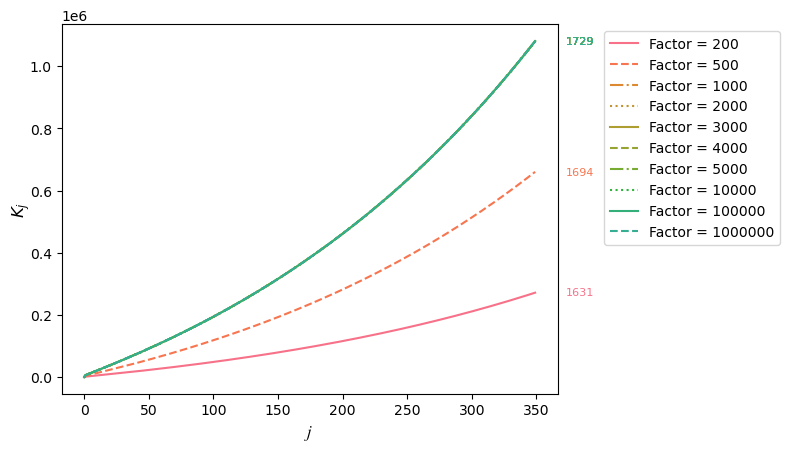

In [47]:
# get K curves for lower bound = 7, alpha = 0.95 and factors = 200, 500, 1000, 10000, 100000, 1000000
# pass in factors
def linear_curve_collation_3(bound, alpha, factors):
    # place to store the K curve information
    # [Kjs, m_0, final_cost, m_values] 
    linear_results = []
    
    for factor in factors:
        K_js, m_0, final_cost, m_values = optimise_kj(N_16, p, alpha, factor, bound)
        linear_results.append([K_js, m_0, final_cost, m_values])
        
    # cost_factors = list(range(200, 1000001, 100000))
    legend_label = "Factor"
    
    # plot the K curves
    func.plot_all_kj(N_16, linear_results, factors, legend_label, alpha)
    
    # store the results in a pickle file
    with open("N_16/much_higher_precomp/lb7_200_1m_t_350.pickle", "wb") as f:
        pickle.dump(linear_results, f)
        
    # print(linear_results[-1][0][-1])
        
# run the function
factors = [200, 500, 1000, 2000, 3000, 4000, 5000, 10000, 100000, 1000000]
# factors 5 to 100
# factors = list(range(5, 101, 5))
# factors 3000 to 4000 in 100 increments
# factors = list(range(3000, 4001, 100))
linear_curve_collation_3(7, 0.95, factors)

In [48]:
reload(func)

# [kjs, m_0, final_cost, m_values]

# read the results in a pickle file
# with open("N_16/much_higher_precomp/lb7_200_1m_t_300.pickle", "rb") as f:
#     linear_results = pickle.load(f)
    
# for item in linear_results:
#     print(item[0][-25])

# function to check if all points in one column are the same
# return an array of true or false for each column
def check_points(results):
    columns = []    # place to store the columns boolean value
    
    # for each column
    for i in range(len(results[0][0])):
        # get the first K curve
        first_curve = results[0][0][i]
        
        # check if all columns are the same
        for j in range(1, len(results)):
            if results[j][0][i] != first_curve:
                columns.append(False)
                break
        else:
            columns.append(True)
        
    # also want to return just a bool if all columns are the same
    all_same = all(columns)
            
    return columns, all_same


# check the columns
# columns, areSame = check_points(linear_results)
# print(areSame)
# print(columns)